# 05 — Visualization

> **Mirrors `src/worldcup/visualization/plots.py`.**
> Every chart here comes from the reusable plotting functions the dashboard also uses — no duplicated plotting code.

In [1]:
import matplotlib.pyplot as plt
from worldcup.data.load import load_results
from worldcup.data.wc2026 import load_groups
from worldcup.features.elo import build_current_ratings
from worldcup.features.build import build_features
from worldcup.models.poisson import train_poisson, predict_match
from worldcup.models.xgboost_model import train_production_xgb, feature_importances
from worldcup.visualization import plots

plots.set_style()
matches = load_results()
groups = load_groups()
elo = build_current_ratings(save=False)

## Data: goal distribution & home advantage

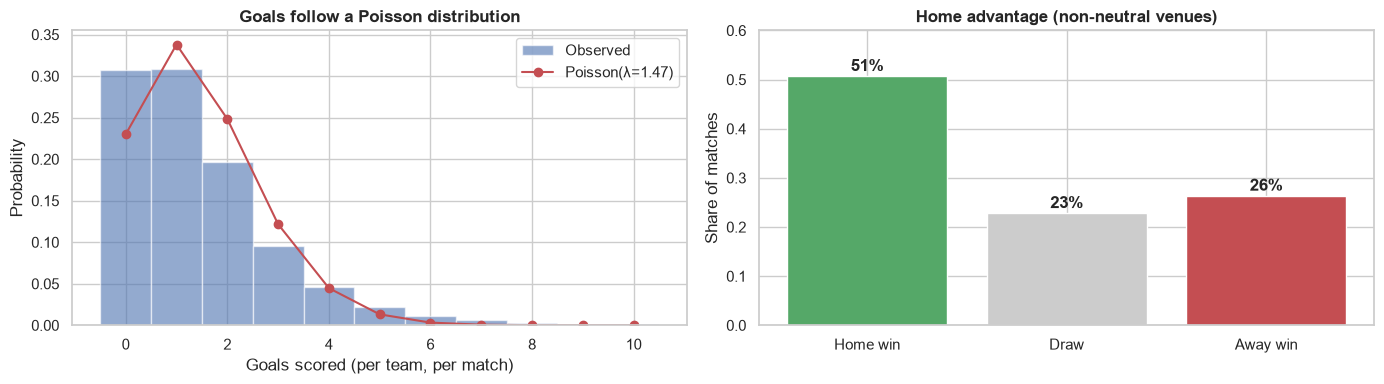

In [2]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4))
plots.plot_goal_distribution(matches, ax=a1)
plots.plot_home_advantage(matches, ax=a2)
plt.tight_layout(); plt.show()

## Ratings: top teams & WC2026 group strength

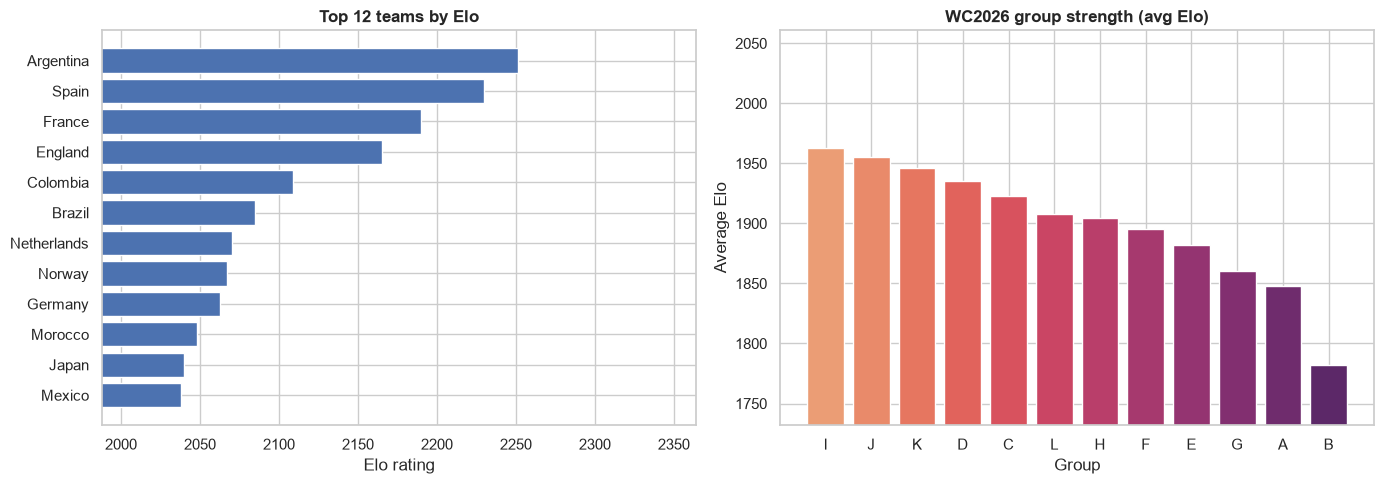

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
plots.plot_top_teams(elo, n=12, ax=a1)
plots.plot_group_strength(groups, elo, ax=a2)
plt.tight_layout(); plt.show()

## Models: feature importance & a Poisson score matrix

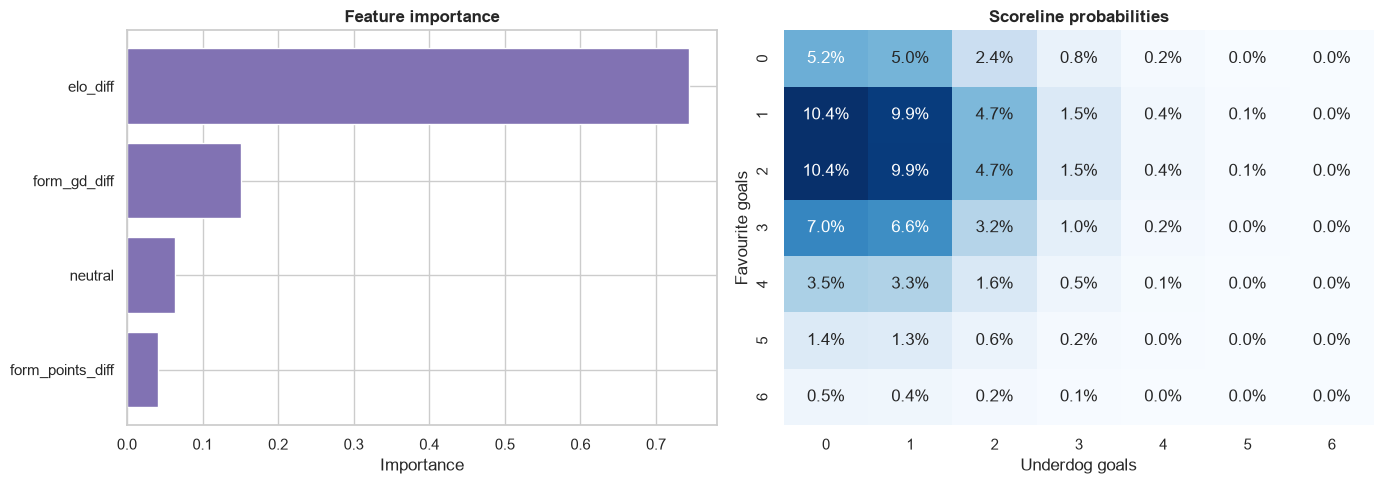

In [4]:
feats = build_features(matches)
imp = feature_importances(train_production_xgb(feats, save=False))
pois = train_poisson(feats, save=False)
matrix = predict_match(pois, {"elo_diff": 180.0, "neutral": 1})["matrix"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
plots.plot_feature_importance(imp, ax=a1)
plots.plot_score_matrix(matrix, "Favourite", "Underdog", ax=a2)
plt.tight_layout(); plt.show()